In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

#### Carico le metriche dai file in formato JSON

In [11]:
evalutaions_df = json.load(open('./results/evaluations.json'))

In [12]:
run_labels = evalutaions_df.keys()
run_labels = list(run_labels)
run_labels = run_labels[0:5]
print('Number of run_labels:',len(run_labels), run_labels)
print('-'*50)

sampling_labels = evalutaions_df[run_labels[0]].keys()
sampling_labels = list(sampling_labels)
print('Number of sampling_labels:',len(sampling_labels), sampling_labels)
print('-'*50)

signature_labels = evalutaions_df[run_labels[0]][sampling_labels[0]].keys()
signature_labels = list(signature_labels)
print('Number of signature_labels:',len(signature_labels), signature_labels)

Number of run_labels: 5 ['run_1', 'run_2', 'run_3', 'run_4', 'run_5']
--------------------------------------------------
Number of sampling_labels: 16 ['sampling_1', 'sampling_0.9', 'sampling_0.8', 'sampling_0.7', 'sampling_0.6', 'sampling_0.5', 'sampling_0.4', 'sampling_0.3', 'sampling_0.2', 'sampling_0.15', 'sampling_0.1', 'sampling_0.05', 'sampling_0.04', 'sampling_0.03', 'sampling_0.02', 'sampling_0.01']
--------------------------------------------------
Number of signature_labels: 29 ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', 'S6 (SBS7a - 1.00)', 'S7 (SBS7b - 0.96)', 'S8 (SBS8 - 0.92)', 'S9 (SBS9 - 0.94)', 'S10 (SBS10a - 1.00)', 'S11 (SBS10d - 0.98)', 'S12 (SBS11 - 0.99)', 'S13 (SBS13 - 0.99)', 'S14 (SBS14 - 0.98)', 'S15 (SBS15 - 0.97)', 'S16 (SBS17 - 0.99)', 'S17 (SBS18 - 0.97)', 'S18 (SBS19 - 0.95)', 'S19 (SBS20 - 0.98)', 'S20 (SBS22 - 0.99)', 'S21 (SBS23 - 0.94)', 'S22 (SBS26 - 0.94)', 'S23 (SBS28 - 0.96)', 'S24 (SBS31 -

# Plot the graphs

In [13]:
per_run_accuracy = []
for run in run_labels:
    per_sample_accuracy = []
    for sampling in sampling_labels:
        per_signature_accuracy = []
        for signature in signature_labels:
            # Save the accuracy of each signarure for one sample
            per_signature_accuracy.append(evalutaions_df[run][sampling][signature]['accuracy'])
        # Here we have the mean accuracy of all signatures for one sample
        per_sample_accuracy.append(per_signature_accuracy)
    # Here we have the mean accuracy of all samples for one run
    per_run_accuracy.append(per_sample_accuracy)

### Accuratezza per signature, per sample, per run
In questi grafici viene mostrato il livello di accuracy ottenuto per ogni segnatura al variare del livello di sampling, per ogni run

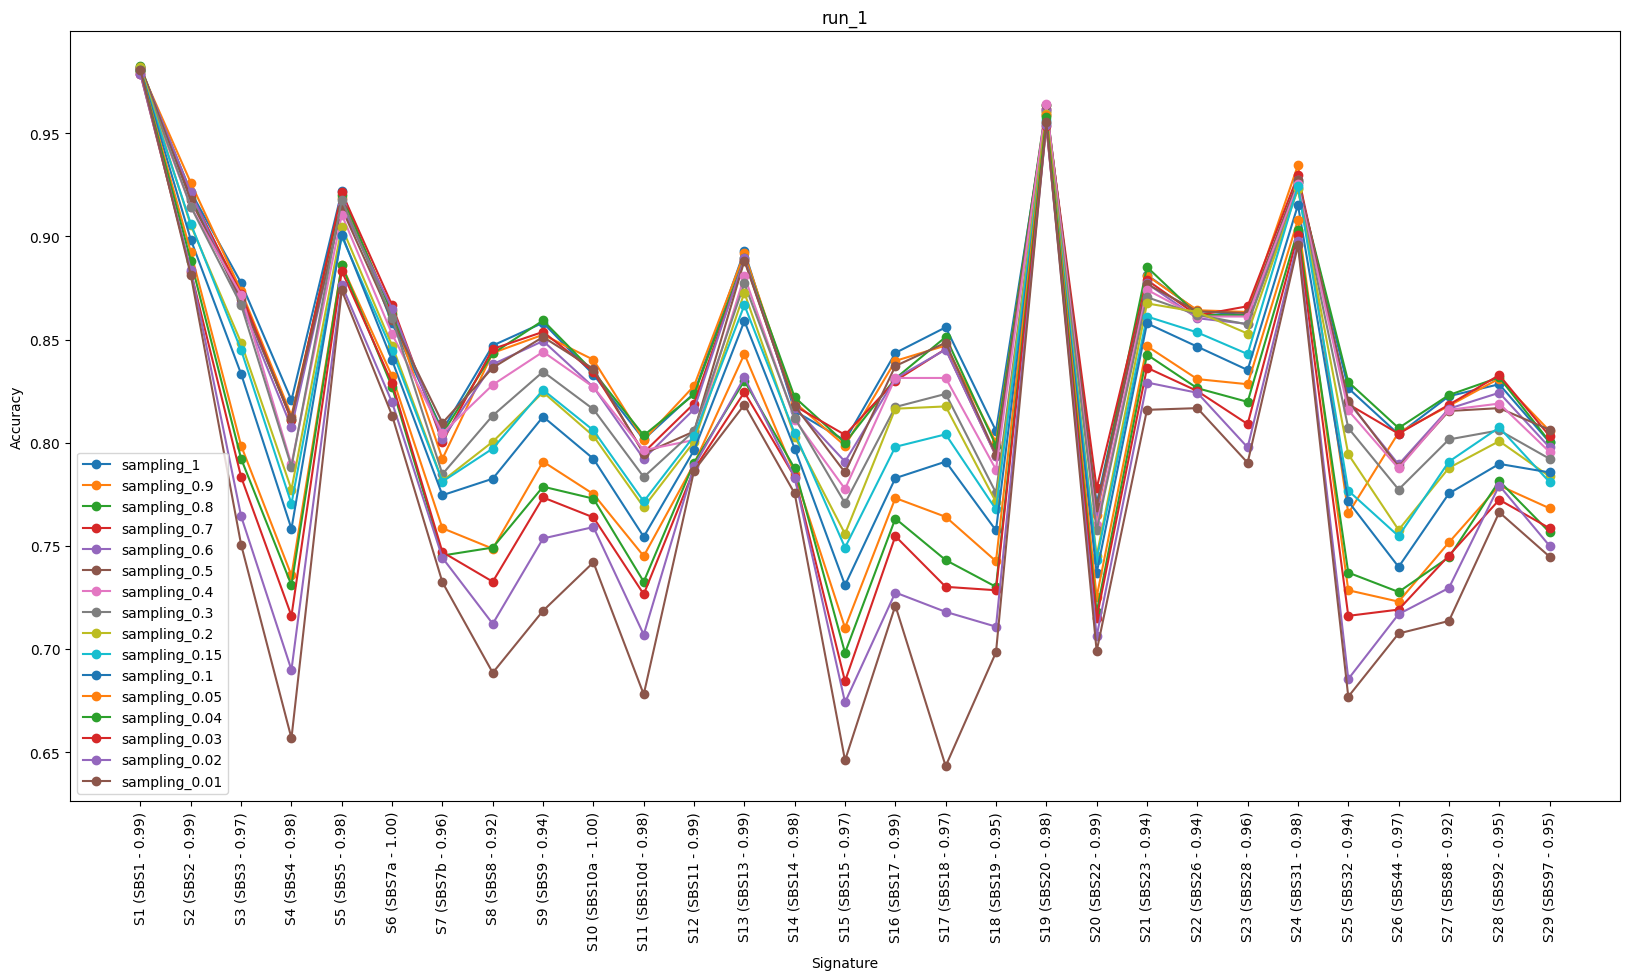

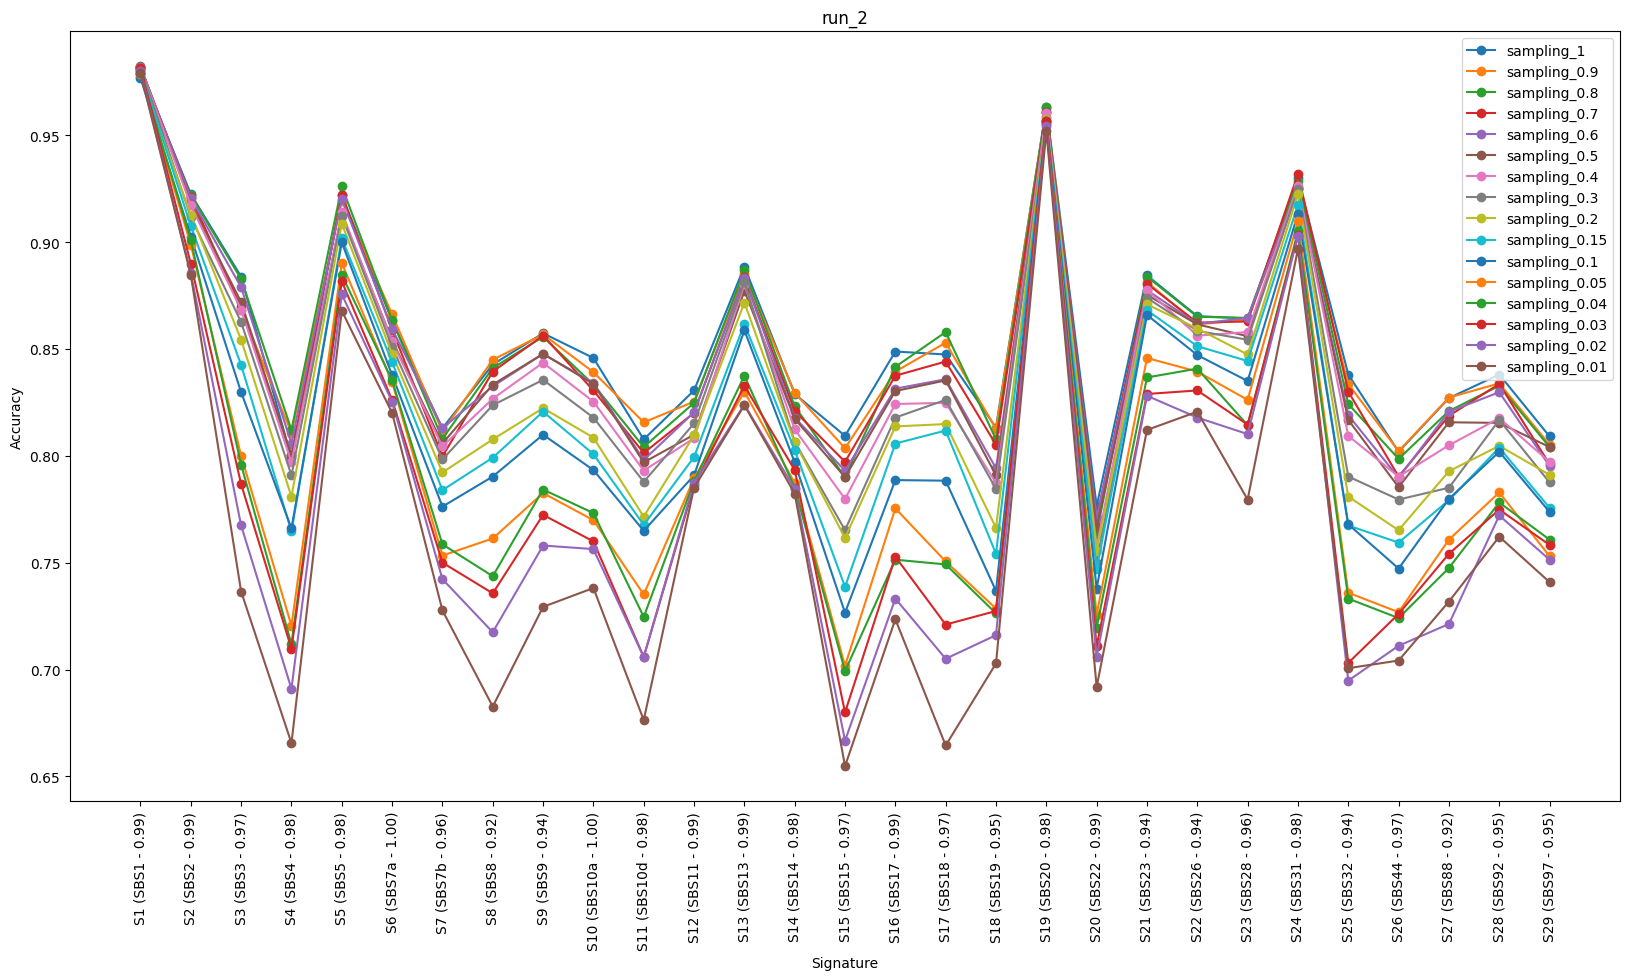

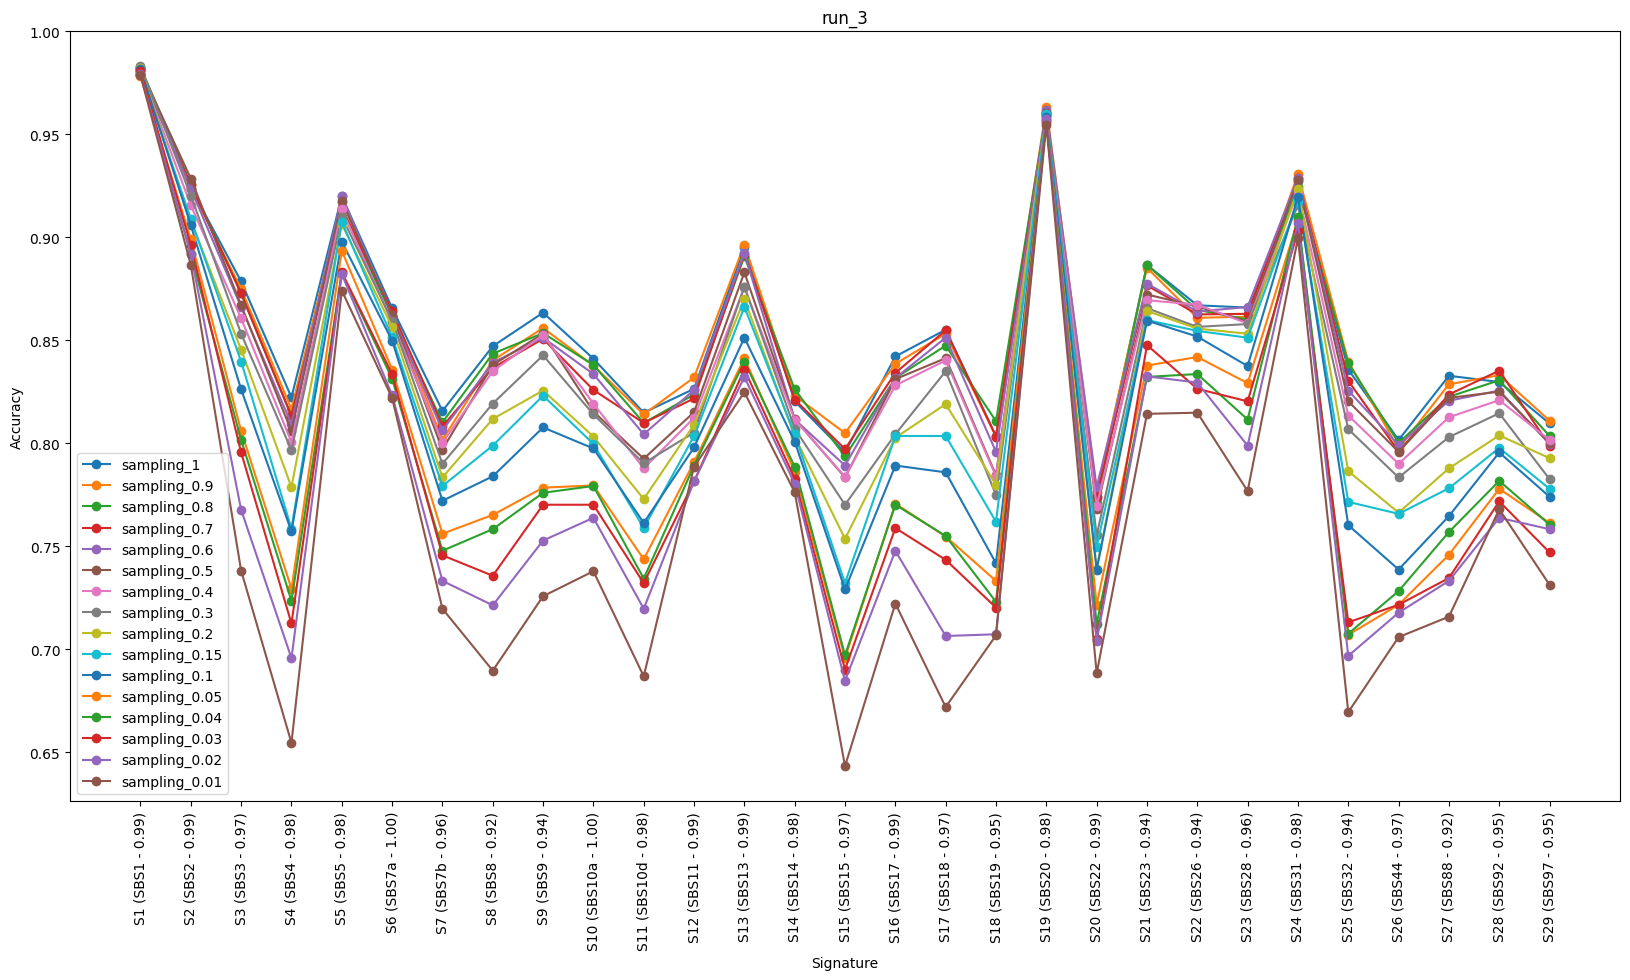

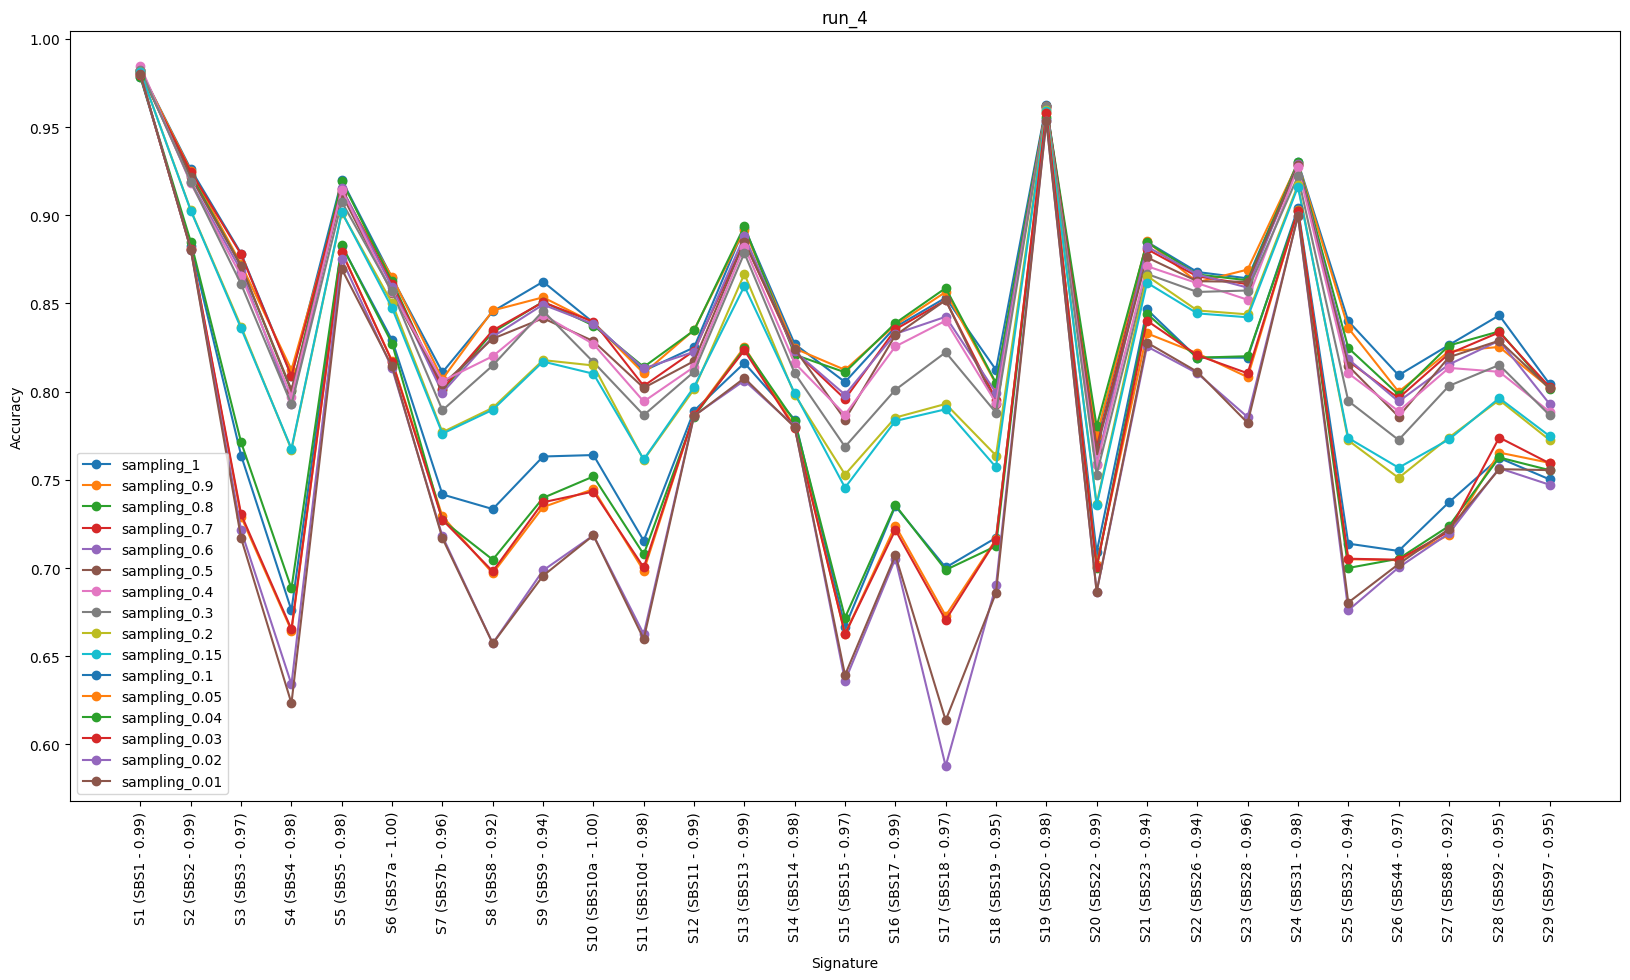

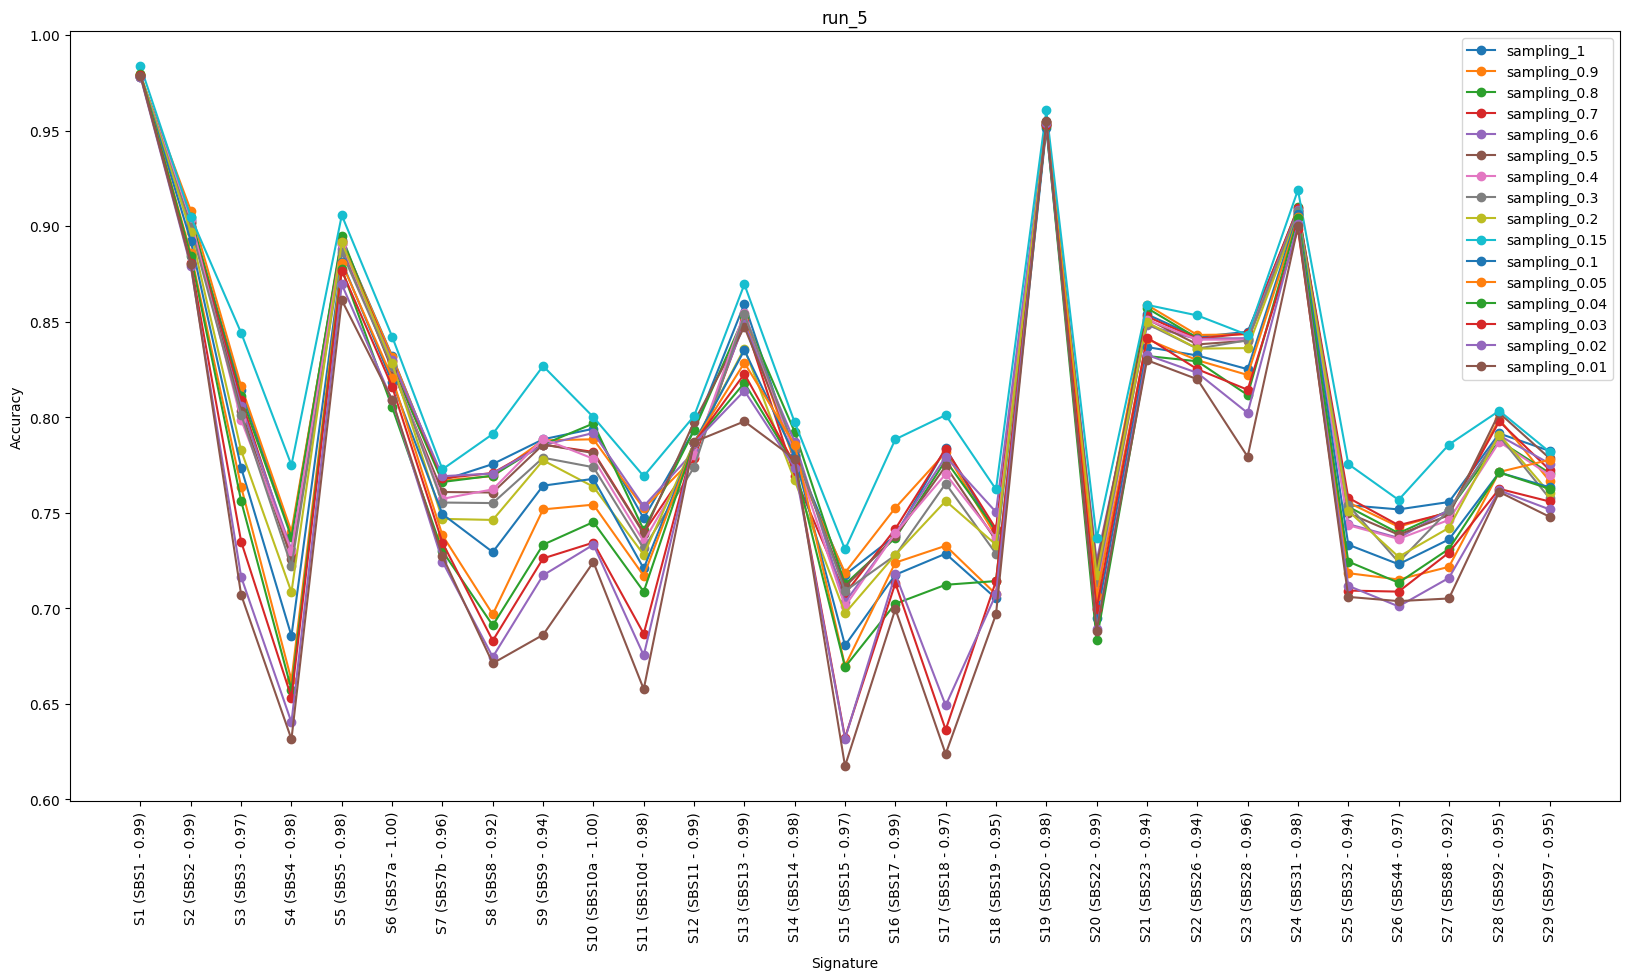

In [14]:
for i in range(len(run_labels)):
    per_sample_accuracy = per_run_accuracy[i]
    plt.figure(i, figsize=(20,10))
    for j in range(len(per_sample_accuracy)):
        plt.plot(signature_labels,per_sample_accuracy[j], marker='o')

    plt.legend(sampling_labels)
    plt.xticks(rotation=90)
    plt.ylabel('Accuracy')
    plt.xlabel('Signature')
    plt.title(run_labels[i])
    plt.show()

### Accuratezza media per sample per run
In questo grafico venogno 

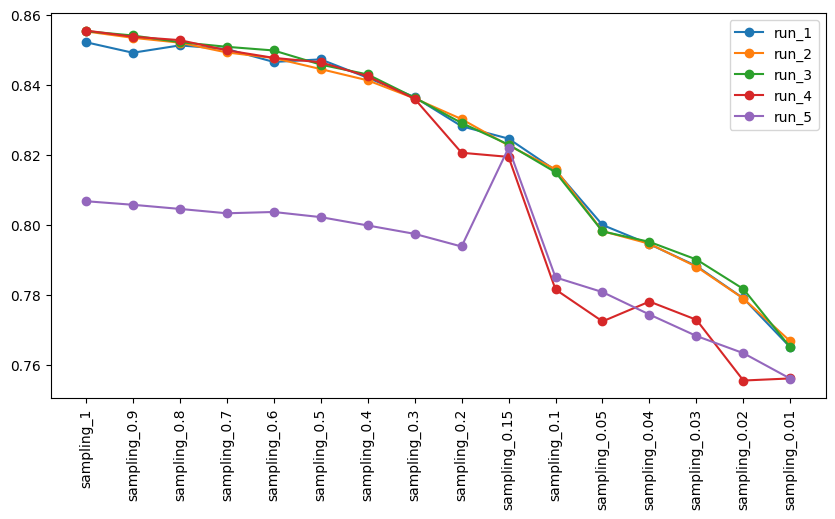

In [15]:
plt.figure(figsize=(10,5))
for i in range(len(per_run_accuracy)):
    per_sample_mean_accuracy = []
    per_sample_accuracy = per_run_accuracy[i]
    for j in range(len(per_sample_accuracy)):
        per_sample_mean_accuracy.append(np.mean(per_sample_accuracy[j]))

    plt.plot(sampling_labels,per_sample_mean_accuracy, marker='o')
    plt.xticks(rotation=90)

plt.legend(run_labels)
plt.show()

### Box-plot (Diagrammi scatola baffo)

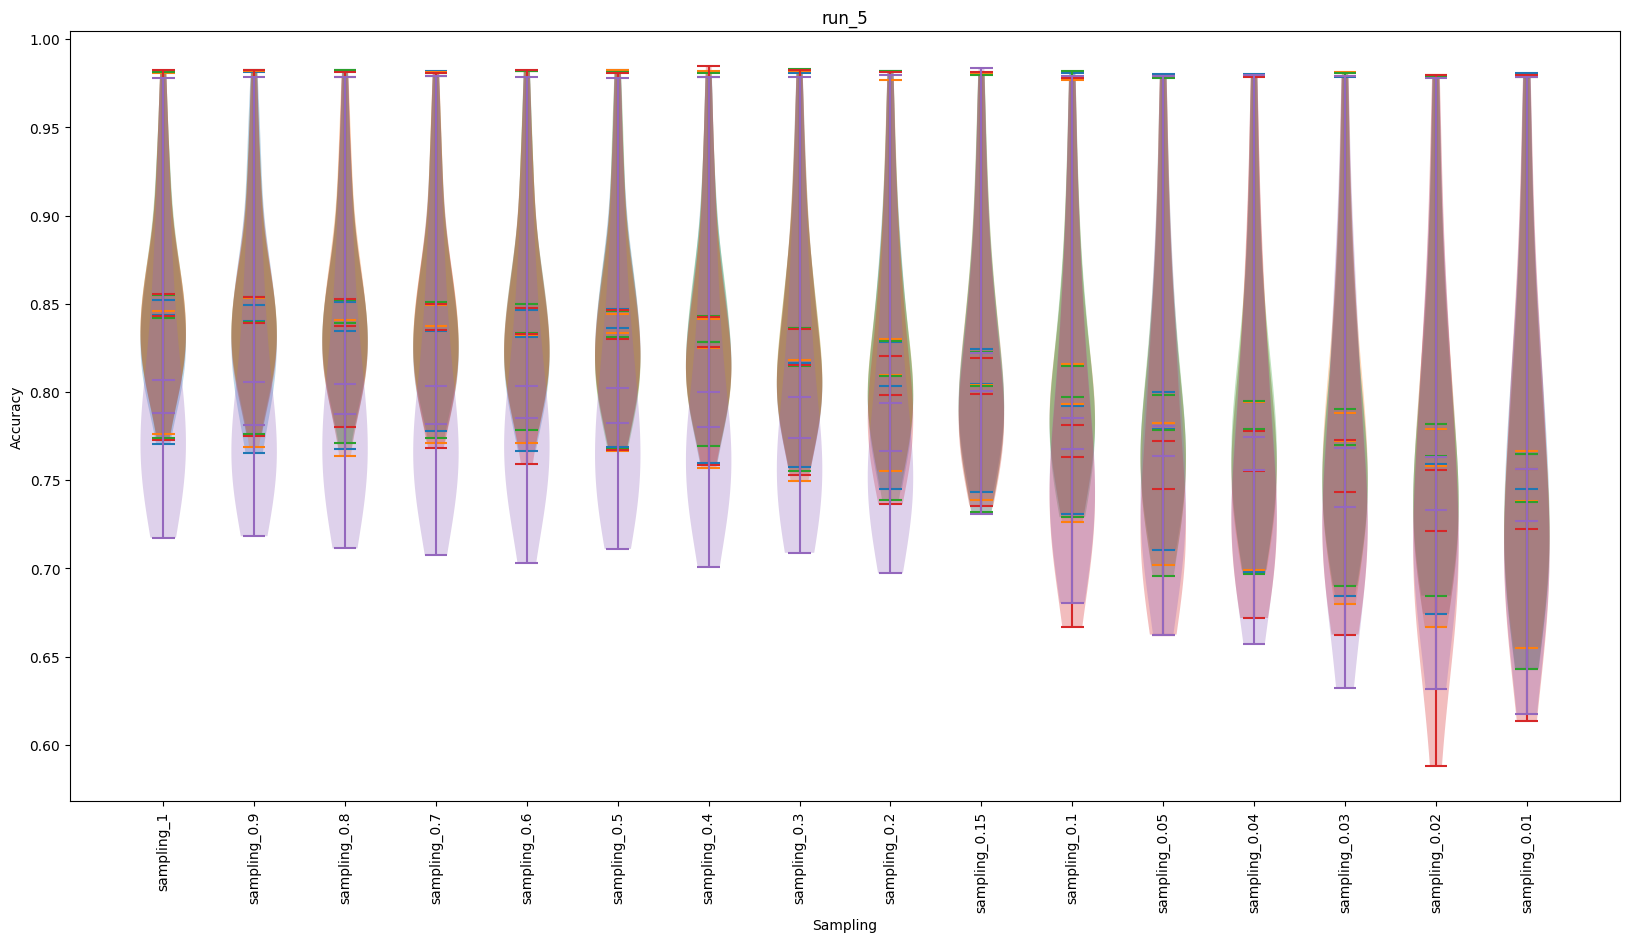

In [16]:
plt.figure(figsize=(20,10))  
plt.xlabel('Sampling')
plt.xticks(range(1,len(sampling_labels)+1), sampling_labels, rotation=90)
plt.ylabel('Accuracy')
for i in range(len(per_run_accuracy)):
    plt.title(run_labels[i])
    plt.violinplot(per_run_accuracy[i], showmeans=True, showmedians=True, showextrema=True)

plt.show()

### ROC Curve & AUC 